# LSTM Forecasting 24 Jam per Pulau (PyTorch)

Notebook ini menyiapkan pipeline forecasting `ALLSKY_SFC_SW_DWN` 24 jam ke depan dengan pendekatan **1 model per `REP_NAME`** menggunakan **PyTorch**.

Spesifikasi:
- Target: `ALLSKY_SFC_SW_DWN`
- Fitur input: `CLOUD_AMT`, `T2M`, `RH2M`, `PS`, `CLRSKY_SFC_SW_DWN` + fitur waktu dari `YEAR/MO/DY/HR`
- Lookback window: 24 jam
- Forecast horizon: 24 jam
- Split: time-based split
- Simpan scaler dan model per pulau
- Siapkan mapping eksternal `REP_NAME -> latitude, longitude` untuk inference Open-Meteo

Catatan:
- Dataset aktual berisi data hourly walaupun nama file mengandung kata `daily`.
- Notebook ini default-nya menjalankan `Jawa` dulu, tetapi fungsi training sudah siap untuk semua `REP_NAME`.

In [13]:
# Jalankan sekali jika environment notebook belum punya dependensi.
# %pip install pandas numpy scikit-learn matplotlib joblib torch jupyter notebook ipykernel


In [14]:
from pathlib import Path
import copy
import json
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device aktif: {DEVICE}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Device aktif: cuda
NVIDIA GeForce RTX 3050 Laptop GPU


In [15]:
DATA_PATH = Path('nasa_dataset_daily_20200101_20260101_representative_point_area.csv')
OUTPUT_DIR = Path('artifacts_lstm_representative_points')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'ALLSKY_SFC_SW_DWN'
MISSING_SENTINEL = -999.0
BASE_FEATURES = ['CLOUD_AMT', 'T2M', 'RH2M', 'PS', 'CLRSKY_SFC_SW_DWN']
LOOKBACK = 24
HORIZON = 24
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
DEFAULT_REGION = 'Jawa'

REP_NAME_ALIASES = {
    'Sumatra': 'Sumatera',
    'Bali_Nusa': 'Nusa Tenggara',
    'NTB_NTT': 'Nusa Tenggara',
}

REPRESENTATIVE_COORDS = {
    'Jawa': {'latitude': None, 'longitude': None},
    'Sumatera': {'latitude': None, 'longitude': None},
    'Kalimantan': {'latitude': None, 'longitude': None},
    'Sulawesi': {'latitude': None, 'longitude': None},
    'Nusa Tenggara': {'latitude': None, 'longitude': None},
    'Maluku': {'latitude': None, 'longitude': None},
    'Papua': {'latitude': None, 'longitude': None},
}

coords_path = OUTPUT_DIR / 'rep_name_coordinates_template.json'
coords_path.write_text(json.dumps(REPRESENTATIVE_COORDS, indent=2), encoding='utf-8')
print(f'Mapping template disimpan ke: {coords_path.resolve()}')


Mapping template disimpan ke: /home/dawwi/AI-Model/artifacts_lstm_representative_points/rep_name_coordinates_template.json


In [16]:
def normalize_rep_name(rep_name: str) -> str:
    return REP_NAME_ALIASES.get(rep_name, rep_name)


def load_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['REP_NAME'] = df['REP_NAME'].astype(str).map(normalize_rep_name)
    numeric_cols = BASE_FEATURES + [TARGET_COL]
    df[numeric_cols] = df[numeric_cols].replace(MISSING_SENTINEL, np.nan)
    df['datetime'] = pd.to_datetime(
        dict(year=df['YEAR'], month=df['MO'], day=df['DY'], hour=df['HR'])
    )
    df = df.sort_values(['REP_NAME', 'datetime']).reset_index(drop=True)
    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour_sin'] = np.sin(2 * np.pi * out['HR'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['HR'] / 24)
    out['month_sin'] = np.sin(2 * np.pi * out['MO'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['MO'] / 12)
    out['dayofyear'] = out['datetime'].dt.dayofyear
    out['dayofyear_sin'] = np.sin(2 * np.pi * out['dayofyear'] / 366)
    out['dayofyear_cos'] = np.cos(2 * np.pi * out['dayofyear'] / 366)
    return out


df_all = load_dataset(DATA_PATH)
df_all = add_time_features(df_all)

TIME_FEATURES = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos']
FEATURE_COLS = BASE_FEATURES + TIME_FEATURES

print(df_all.head())
print('\nJumlah missing value setelah konversi sentinel -999 -> NaN:')
print(df_all[BASE_FEATURES + [TARGET_COL]].isna().sum())
print('\nJumlah baris per REP_NAME:')
print(df_all['REP_NAME'].value_counts().sort_index())


   YEAR  MO  DY  HR  CLOUD_AMT    T2M   RH2M     PS  CLRSKY_SFC_SW_DWN  \
0  2020   1   1   0      98.61  25.34  89.43  98.67             394.12   
1  2020   1   1   1      98.83  25.93  83.58  98.73             622.78   
2  2020   1   1   2      99.72  26.94  78.75  98.74             809.80   
3  2020   1   1   3      99.99  28.08  75.40  98.70             936.25   
4  2020   1   1   4      99.71  28.58  75.06  98.65             991.17   

   ALLSKY_SFC_SW_DWN REP_NAME            datetime  hour_sin  hour_cos  \
0             268.55     Jawa 2020-01-01 00:00:00  0.000000  1.000000   
1             441.62     Jawa 2020-01-01 01:00:00  0.258819  0.965926   
2             610.35     Jawa 2020-01-01 02:00:00  0.500000  0.866025   
3             575.12     Jawa 2020-01-01 03:00:00  0.707107  0.707107   
4             518.35     Jawa 2020-01-01 04:00:00  0.866025  0.500000   

   month_sin  month_cos  dayofyear  dayofyear_sin  dayofyear_cos  
0        0.5   0.866025          1       0.017166

In [17]:
def time_based_split(region_df: pd.DataFrame, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO):
    n = len(region_df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = region_df.iloc[:train_end].copy()
    val_df = region_df.iloc[train_end:val_end].copy()
    test_df = region_df.iloc[val_end:].copy()

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        if len(split_df) < LOOKBACK + HORIZON:
            raise ValueError(f'Split {split_name} terlalu kecil untuk LOOKBACK={LOOKBACK} dan HORIZON={HORIZON}')

    return train_df, val_df, test_df


def create_sequences(feature_array: np.ndarray, target_array: np.ndarray, lookback: int = LOOKBACK, horizon: int = HORIZON):
    X, y = [], []
    max_start = len(feature_array) - lookback - horizon + 1
    for start_idx in range(max_start):
        end_idx = start_idx + lookback
        horizon_end = end_idx + horizon
        X.append(feature_array[start_idx:end_idx])
        y.append(target_array[end_idx:horizon_end, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def prepare_region_data(df: pd.DataFrame, region_name: str):
    region_name = normalize_rep_name(region_name)
    region_df = df.loc[df['REP_NAME'] == region_name].copy()
    if region_df.empty:
        raise ValueError(f'REP_NAME {region_name} tidak ditemukan di dataset.')

    required_cols = BASE_FEATURES + [TARGET_COL]
    missing_rows = int(region_df[required_cols].isna().any(axis=1).sum())
    if missing_rows > 0:
        print(f'Menghapus {missing_rows} baris dengan missing value pada {region_name}.')
    region_df = region_df.dropna(subset=required_cols).copy()

    train_df, val_df, test_df = time_based_split(region_df)

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    train_X_raw = train_df[FEATURE_COLS].values
    val_X_raw = val_df[FEATURE_COLS].values
    test_X_raw = test_df[FEATURE_COLS].values

    train_y_raw = train_df[[TARGET_COL]].values
    val_y_raw = val_df[[TARGET_COL]].values
    test_y_raw = test_df[[TARGET_COL]].values

    train_X_scaled = x_scaler.fit_transform(train_X_raw)
    val_X_scaled = x_scaler.transform(val_X_raw)
    test_X_scaled = x_scaler.transform(test_X_raw)

    train_y_scaled = y_scaler.fit_transform(train_y_raw)
    val_y_scaled = y_scaler.transform(val_y_raw)
    test_y_scaled = y_scaler.transform(test_y_raw)

    X_train, y_train = create_sequences(train_X_scaled, train_y_scaled)
    X_val, y_val = create_sequences(val_X_scaled, val_y_scaled)
    X_test, y_test = create_sequences(test_X_scaled, test_y_scaled)

    metadata = {
        'region_name': region_name,
        'n_rows': int(len(region_df)),
        'dropped_missing_rows': missing_rows,
        'train_rows': int(len(train_df)),
        'val_rows': int(len(val_df)),
        'test_rows': int(len(test_df)),
        'train_range': [str(train_df['datetime'].min()), str(train_df['datetime'].max())],
        'val_range': [str(val_df['datetime'].min()), str(val_df['datetime'].max())],
        'test_range': [str(test_df['datetime'].min()), str(test_df['datetime'].max())],
        'feature_columns': FEATURE_COLS,
        'target_column': TARGET_COL,
        'lookback': LOOKBACK,
        'horizon': HORIZON,
    }

    return {
        'region_df': region_df,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
        'x_scaler': x_scaler,
        'y_scaler': y_scaler,
        'metadata': metadata,
    }


region_bundle = prepare_region_data(df_all, DEFAULT_REGION)
for key in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']:
    print(key, region_bundle[key].shape)


Menghapus 24 baris dengan missing value pada Jawa.
X_train (36778, 24, 11)
y_train (36778, 24)
X_val (7844, 24, 11)
y_val (7844, 24)
X_test (7845, 24, 11)
y_test (7845, 24)


In [18]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, horizon: int = HORIZON, dropout: float = 0.2):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.head(last_hidden)


def build_dataloaders(bundle, batch_size: int = 32):
    train_ds = TensorDataset(torch.from_numpy(bundle['X_train']), torch.from_numpy(bundle['y_train']))
    val_ds = TensorDataset(torch.from_numpy(bundle['X_val']), torch.from_numpy(bundle['y_val']))
    test_ds = TensorDataset(torch.from_numpy(bundle['X_test']), torch.from_numpy(bundle['y_test']))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


sample_model = LSTMForecaster(input_size=len(FEATURE_COLS)).to(DEVICE)
sample_model


LSTMForecaster(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=24, bias=True)
  )
)

In [19]:
def inverse_transform_targets(y_scaled: np.ndarray, scaler: MinMaxScaler) -> np.ndarray:
    original_shape = y_scaled.shape
    flat = y_scaled.reshape(-1, 1)
    restored = scaler.inverse_transform(flat)
    return restored.reshape(original_shape)


def evaluate_forecast(y_true_scaled: np.ndarray, y_pred_scaled: np.ndarray, y_scaler: MinMaxScaler):
    y_true = inverse_transform_targets(y_true_scaled, y_scaler)
    y_pred = inverse_transform_targets(y_pred_scaled, y_scaler)
    rmse = float(np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))))
    mae = float(mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1)))
    per_horizon_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    return {
        'rmse_all_steps': rmse,
        'mae_all_steps': mae,
        'rmse_per_horizon': per_horizon_rmse.tolist(),
        'y_true': y_true,
        'y_pred': y_pred,
    }


def predict_loader(model, data_loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(DEVICE)
            outputs = model(batch_x).cpu().numpy()
            preds.append(outputs)
            targets.append(batch_y.numpy())
    return np.concatenate(preds, axis=0), np.concatenate(targets, axis=0)


def save_artifacts(region_name: str, model, x_scaler, y_scaler, metadata: dict):
    region_dir = OUTPUT_DIR / region_name.replace(' ', '_')
    region_dir.mkdir(parents=True, exist_ok=True)

    model_path = region_dir / 'lstm_model.pt'
    x_scaler_path = region_dir / 'x_scaler.joblib'
    y_scaler_path = region_dir / 'y_scaler.joblib'
    metadata_path = region_dir / 'metadata.json'

    torch.save(model.state_dict(), model_path)
    joblib.dump(x_scaler, x_scaler_path)
    joblib.dump(y_scaler, y_scaler_path)
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

    return {
        'region_dir': region_dir,
        'model_path': model_path,
        'x_scaler_path': x_scaler_path,
        'y_scaler_path': y_scaler_path,
        'metadata_path': metadata_path,
    }


def train_region_model(df: pd.DataFrame, region_name: str, epochs: int = 40, batch_size: int = 32, learning_rate: float = 1e-3):
    bundle = prepare_region_data(df, region_name)
    train_loader, val_loader, test_loader = build_dataloaders(bundle, batch_size=batch_size)

    model = LSTMForecaster(input_size=len(FEATURE_COLS)).to(DEVICE)
    criterion = nn.HuberLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience = 8
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(DEVICE)
                batch_y = batch_y.to(DEVICE)
                preds = model(batch_x)
                loss = criterion(preds, batch_y)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        print(f'Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping aktif.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    y_pred_scaled, y_test_scaled = predict_loader(model, test_loader)
    metrics = evaluate_forecast(y_test_scaled, y_pred_scaled, bundle['y_scaler'])

    bundle['metadata']['metrics'] = {
        'rmse_all_steps': metrics['rmse_all_steps'],
        'mae_all_steps': metrics['mae_all_steps'],
        'rmse_horizon_1': metrics['rmse_per_horizon'][0],
        'rmse_horizon_24': metrics['rmse_per_horizon'][-1],
        'best_val_loss': best_val_loss,
    }

    bundle['metadata']['model_config'] = {
        'framework': 'pytorch',
        'input_size': len(FEATURE_COLS),
        'hidden_size': 64,
        'num_layers': 2,
        'dropout': 0.2,
    }

    artifact_paths = save_artifacts(
        region_name=normalize_rep_name(region_name),
        model=model,
        x_scaler=bundle['x_scaler'],
        y_scaler=bundle['y_scaler'],
        metadata=bundle['metadata'],
    )

    return {
        'history': history,
        'model': model,
        'bundle': bundle,
        'metrics': metrics,
        'artifact_paths': artifact_paths,
    }


In [20]:
# Training awal untuk Jawa dulu.
jawa_result = train_region_model(df_all, DEFAULT_REGION, epochs=40, batch_size=32)

print('RMSE semua horizon:', jawa_result['metrics']['rmse_all_steps'])
print('MAE semua horizon :', jawa_result['metrics']['mae_all_steps'])
print('Artifact folder    :', jawa_result['artifact_paths']['region_dir'].resolve())


Menghapus 24 baris dengan missing value pada Jawa.
Epoch 01/40 | train_loss=0.00668 | val_loss=0.00434
Epoch 02/40 | train_loss=0.00361 | val_loss=0.00336
Epoch 03/40 | train_loss=0.00334 | val_loss=0.00385
Epoch 04/40 | train_loss=0.00328 | val_loss=0.00387
Epoch 05/40 | train_loss=0.00323 | val_loss=0.00388
Epoch 06/40 | train_loss=0.00319 | val_loss=0.00363
Epoch 07/40 | train_loss=0.00315 | val_loss=0.00324
Epoch 08/40 | train_loss=0.00315 | val_loss=0.00306
Epoch 09/40 | train_loss=0.00311 | val_loss=0.00303
Epoch 10/40 | train_loss=0.00311 | val_loss=0.00308
Epoch 11/40 | train_loss=0.00310 | val_loss=0.00282
Epoch 12/40 | train_loss=0.00306 | val_loss=0.00319
Epoch 13/40 | train_loss=0.00306 | val_loss=0.00275
Epoch 14/40 | train_loss=0.00306 | val_loss=0.00280
Epoch 15/40 | train_loss=0.00305 | val_loss=0.00258
Epoch 16/40 | train_loss=0.00303 | val_loss=0.00245
Epoch 17/40 | train_loss=0.00301 | val_loss=0.00242
Epoch 18/40 | train_loss=0.00301 | val_loss=0.00249
Epoch 19/40 |

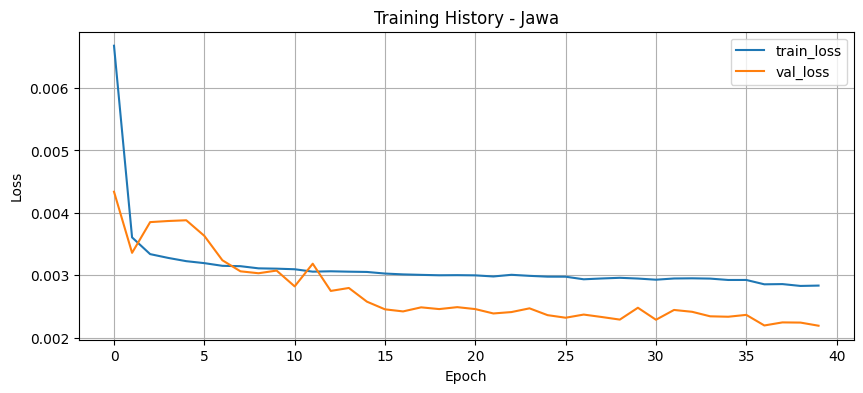

In [25]:
history = jawa_result['history']

plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.title('Training History - Jawa')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


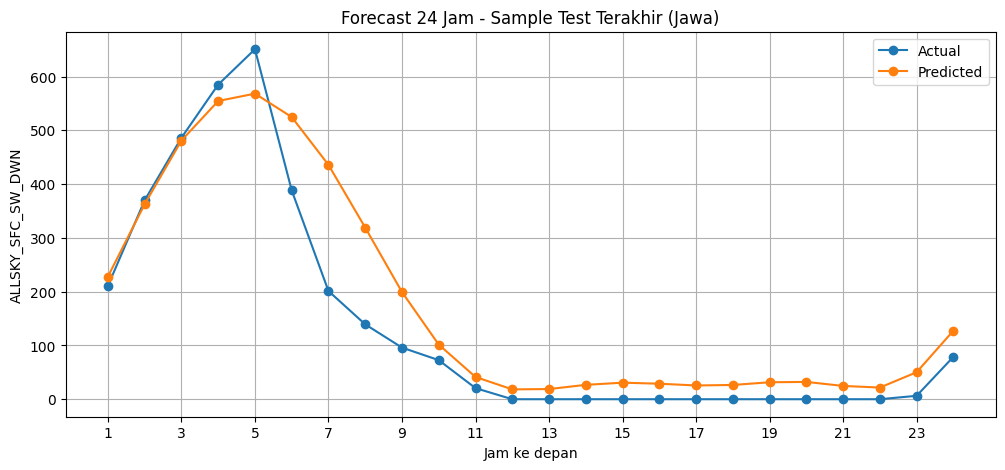

In [22]:
sample_idx = -1
y_true = jawa_result['metrics']['y_true'][sample_idx]
y_pred = jawa_result['metrics']['y_pred'][sample_idx]

plt.figure(figsize=(12, 5))
plt.plot(range(1, HORIZON + 1), y_true, marker='o', label='Actual')
plt.plot(range(1, HORIZON + 1), y_pred, marker='o', label='Predicted')
plt.title('Forecast 24 Jam - Sample Test Terakhir (Jawa)')
plt.xlabel('Jam ke depan')
plt.ylabel(TARGET_COL)
plt.xticks(range(1, HORIZON + 1, 2))
plt.grid(True)
plt.legend()
plt.show()


In [23]:
# Jika nanti ingin training semua pulau, buka komentar pada sel ini.
# all_results = {}
# for region_name in sorted(df_all['REP_NAME'].unique()):
#     print(f'\n=== Training {region_name} ===')
#     all_results[region_name] = train_region_model(df_all, region_name, epochs=40, batch_size=32)
#     print(all_results[region_name]['artifact_paths']['region_dir'].resolve())


In [24]:
def load_region_artifacts(region_name: str):
    region_name = normalize_rep_name(region_name)
    region_dir = OUTPUT_DIR / region_name.replace(' ', '_')
    metadata = json.loads((region_dir / 'metadata.json').read_text(encoding='utf-8'))
    model_cfg = metadata['model_config']

    model = LSTMForecaster(
        input_size=model_cfg['input_size'],
        hidden_size=model_cfg['hidden_size'],
        num_layers=model_cfg['num_layers'],
        horizon=metadata['horizon'],
        dropout=model_cfg['dropout'],
    ).to(DEVICE)
    model.load_state_dict(torch.load(region_dir / 'lstm_model.pt', map_location=DEVICE))
    model.eval()

    x_scaler = joblib.load(region_dir / 'x_scaler.joblib')
    y_scaler = joblib.load(region_dir / 'y_scaler.joblib')
    return model, x_scaler, y_scaler, metadata


def forecast_next_24_hours_from_recent_window(recent_window_df: pd.DataFrame, model, x_scaler, y_scaler):
    if len(recent_window_df) != LOOKBACK:
        raise ValueError(f'recent_window_df harus berisi tepat {LOOKBACK} baris.')

    recent_window_df = add_time_features(recent_window_df.copy())
    X_recent = recent_window_df[FEATURE_COLS].values
    X_recent_scaled = x_scaler.transform(X_recent).astype(np.float32)
    X_recent_tensor = torch.from_numpy(X_recent_scaled).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_scaled = model(X_recent_tensor).cpu().numpy()

    pred = inverse_transform_targets(pred_scaled, y_scaler)[0]
    return pred


trained_model, saved_x_scaler, saved_y_scaler, saved_metadata = load_region_artifacts('Jawa')
recent_window = (
    df_all.loc[df_all['REP_NAME'] == 'Jawa']
    .dropna(subset=BASE_FEATURES + [TARGET_COL])
    .tail(LOOKBACK)
    .copy()
)
forecast_24h = forecast_next_24_hours_from_recent_window(recent_window, trained_model, saved_x_scaler, saved_y_scaler)

forecast_df = pd.DataFrame({
    'horizon_hour': np.arange(1, HORIZON + 1),
    'predicted_ALLSKY_SFC_SW_DWN': forecast_24h,
})
forecast_df.head()


,horizon_hour,predicted_ALLSKY_SFC_SW_DWN
0,1,223.655746
1,2,354.803772
2,3,472.036743
3,4,547.367859
4,5,564.447021


## Catatan untuk langkah berikutnya

Untuk integrasi Open-Meteo nanti:
- isi `rep_name_coordinates_template.json` dengan koordinat titik representatif final per `REP_NAME`
- ambil data cuaca dari koordinat tersebut
- bentuk 24 baris input terbaru sesuai `FEATURE_COLS`
- panggil `forecast_next_24_hours_from_recent_window(...)`

Versi ini memakai lookback 24 jam untuk memprediksi 24 jam ke depan sesuai spesifikasi awal. Jika nanti Anda ingin memakai future exogenous features dari Open-Meteo juga, kita bisa upgrade arsitekturnya ke encoder-decoder atau direct multi-input forecasting.